# **Introduction to OpenCV**
## Image Processing and Computer Vision


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
print("The OpenCV version is:", cv2.__version__)

The OpenCV version is: 4.13.0


## Create and visualization

All the images can be **represented as a matrix** of pixels with n columns and m rows. Each pixel represents the data (sampled and quantized) measured by a sensor.

As a first example, I have generated an images (matrix) with random values



In [3]:
#Example
img_random = np.random.randint(0,256,(7,9), dtype=np.uint8)

**Numerical visualization**

In [4]:
img = np.random.randint(0,256,(7,9), dtype=np.uint8)
print(img, img.shape, img.dtype)

[[ 47  72   4 184 136 133  49 114 202]
 [ 58 246 112 154 119  57 245 225 119]
 [ 85 245  75  59 248 220  51  53 134]
 [186  24 157 106  53 216 130  51   4]
 [201 206 254   6  48  29 217   9  71]
 [179 151 254 252  43 162 217 207  27]
 [132  30 142 194  12 244   3  79  23]] (7, 9) uint8


**Matplotlib visualization**

- **plt.imshow**: function in Python is used to display images in a plot
- **plt.subplot**: draw multiple plots in one figure
- **plt.show**: is used to display all figures (display all open figures)
- **plt.figure**: is used to create a new figure for our plots.
- **plt.title**: is used to specify the title of the visualization depicted and display the title using various attributes.
- **plt.axis**: is used to get or set properties of the x- and y-axis in a plot.
- All the values in the matrix are represented with a specific value of the gray scale

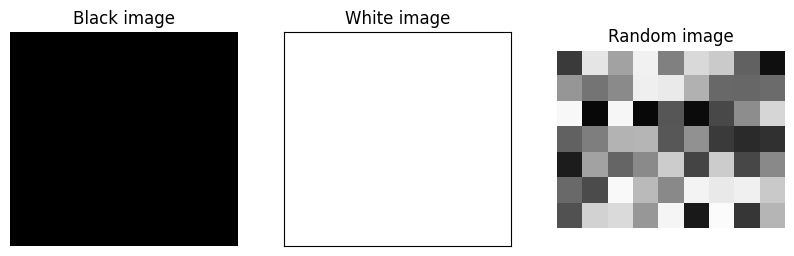

In [5]:
img_random = np.random.randint(0,256,(7,9), dtype=np.uint8)
img_black = np.zeros((15, 16), dtype=np.uint8) # All pixels have zero value (black image)
img_white = np.full((15, 16), 255, dtype=np.uint8) # All pixels have 255 value (white image)

#Create a figure where are displyed several images
plt.figure(figsize=(10,10)) #(width, height)

plt.subplot(1,3,1)
plt.imshow(img_black, cmap="gray", vmin=0, vmax=255)
plt.title("Black image")
plt.axis("off") #hide the axis labels

plt.subplot(1,3,2)
plt.imshow(img_white, cmap="gray", vmin=0, vmax=255)
plt.title("White image")
plt.xticks([]) #I have used xticks to keep the contours and remove the values of the X-axis
plt.yticks([]) #I have used yticks to keep the contours and remove the values of the Y-axis

plt.subplot(1,3,3)
plt.imshow(img_random, cmap = "gray", vmin=0, vmax=255)
plt.title("Random image")
plt.axis("off") #hide the axis labels

plt.show()



## Import image

The most frequent way to deal with image is to import it using the OpenCV library

**OpenCV + Matplotlib visualization**

- **cv2.imread**: OpenCV reads the image (return a **NumPy array** if the image is loaded successfully). If no flag is specified, imread() loads the image in **BGR format** by default
- **cv2.cvtColor**: OpenCV converts an image from one color space to another. We usually want to convert from **BGR** to **RGB** (standard format)
- Matplotlib is used to print the image

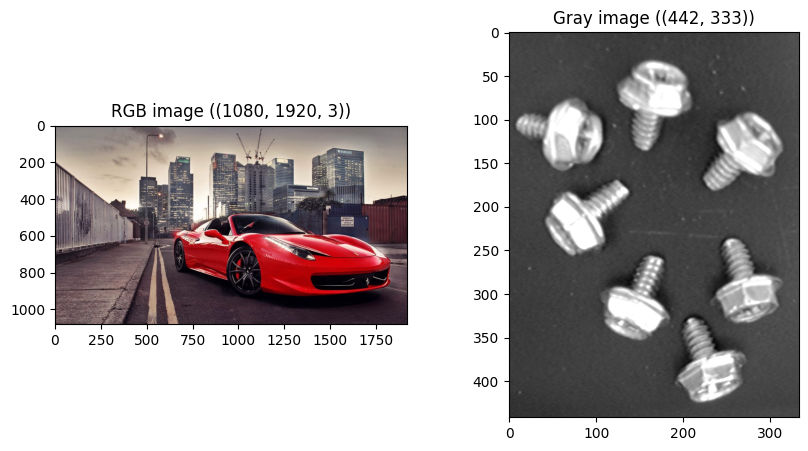

In [6]:
IMG_PATH_RGB = "./img/ferrari.jpg"
IMG_PATH_GRAY = "./img/bolts.png"

#READ rgb image
img_rgb = cv2.imread(IMG_PATH_RGB) #read the image and return the numpy array in BGR format
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB) #convert the color space from BGR to RGB


#READ gray image

#1° method
img_gray = cv2.imread(IMG_PATH_GRAY,  cv2.IMREAD_GRAYSCALE) #read the image and return the numpy array in gray format

#2° method
#img_gray = cv2.imread(IMG_PATH_GRAY) #read the image and return the numpy array in BGR format (it's like a gray image with 3 channels)
#img_gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY) #convert the color space from BGR to gray

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("RGB image (" + str(img_rgb.shape) +  ")")

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap="gray")
plt.title("Gray image (" + str(img_gray.shape) +  ")")

plt.show()

Note:
- RGB image has 3 channels
- gray scale image has just 1 channel 
- if I read the gray image as a rgb image (e.g. using the code for rgb image), I get 3 channels (and not just one)

---


In [7]:
print(f"Shape of image: {img_rgb.shape}")

H = img_rgb.shape[0]
W = img_rgb.shape[1]
C = img_rgb.shape[2]

print(f"The height is: {H}.")
print(f"The width is: {W}.")
print(f"The number of channels is: {C}.")

Shape of image: (1080, 1920, 3)
The height is: 1080.
The width is: 1920.
The number of channels is: 3.


The shape $(H,W,C)$ represents the **height**, **width** and **number of channels** of the image.

---


The images are represented with a Numpy array (so we are able to use all NumPy methods also on images)

In [8]:
print(f"The images are represented as: {type(img_rgb)}")

The images are represented as: <class 'numpy.ndarray'>


---

Moreover, if you want to get the bit-depth (the number of bits per pixel) of an image you can inspect the type of the array:

In [9]:
img_rgb.dtype

dtype('uint8')

Images usually have 8-bit depth, therefore, each pixel contains a value from $0$ to $2^8 - 1 = 255$.

## Accessing the image pixels 

In Python we can say that an image is represented as a **matrix**.
Each element of the matrix represents one **pixel**.

Since a color image has 3 channels per pixel, our representation is not a simple matrix, but rather 3-dimensional representation called **tensor**.

So let's try to access one random pixel, for example one belonging to Ironman's suit:

In [10]:
car_pixel = img_rgb[800, 1250] #[height, width]

print(f"The pixel value is: {car_pixel}.")

The pixel value is: [177   3   4].


So now we know that an RGB image has 3 values per pixel representing the red, green and blue channels.

In [11]:
# Accessing blue, green and red values of the pixel

red = car_pixel[0]
green = car_pixel[1]
blue = car_pixel[2]

#ALTERNATIVE: direct access
#red = img_rgb[800, 1250, 0]
#green = img_rgb[800, 1250, 1]
#blue = img_rgb[800, 1250, 2]

print(f"The RGB value of the pixel is: R = {red}, G = {green}, B = {blue}.")

The RGB value of the pixel is: R = 177, G = 3, B = 4.


Gray-scale image: each pixel is not a vector anymore, but a single intensity value between 0 and 255:

In [12]:
gray_pixel = img_gray[200,150]

print(gray_pixel)

111


## Accessing RGB channels separately

In colored images each RGB channel can be seen as a single grayscale image and can be plot independently: a channel in this context is the grayscale image of the same size as a color image, made of just one of these primary colors.

So let us extract the 3 channels representing the RGB values of the image and plot them in three different grayscale images:

**1° method**

In [13]:
R = img_rgb[:,:,0]  # Getting the first axis (R)
G = img_rgb[:,:,1]  # Getting the second axis (G)
B = img_rgb[:,:,2]  # Getting the third axis (B)

# Each channel can be seen as a grayscale image
print(R.shape, G.shape, B.shape)

(1080, 1920) (1080, 1920) (1080, 1920)


Plot using **cmap="gray"**

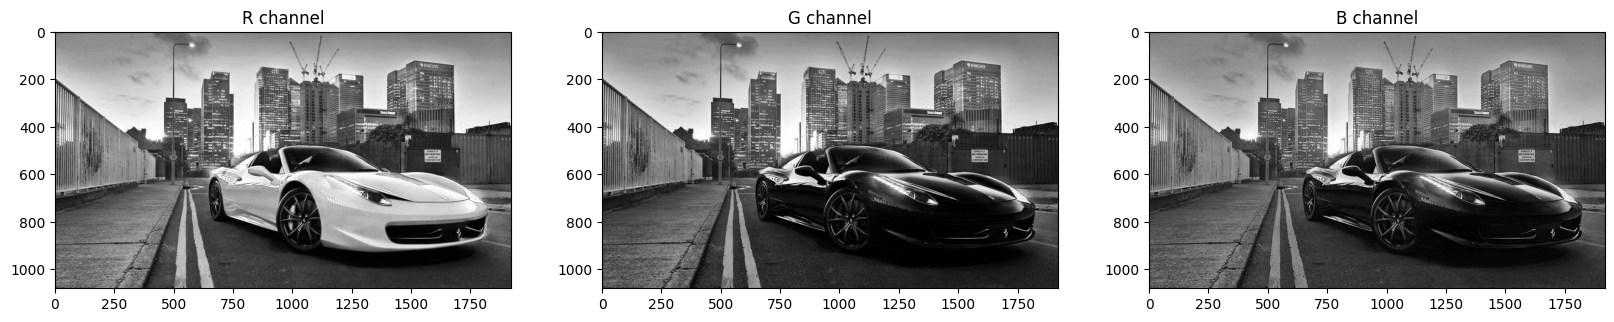

In [15]:
plt.figure(figsize = (20, 10))

plt.subplot(1,3,1)
plt.imshow(R, cmap="gray", vmin=0, vmax=255)
plt.title("R channel")

plt.subplot(1,3,2)
plt.imshow(G, cmap="gray", vmin=0, vmax=255)
plt.title("G channel")

plt.subplot(1,3,3)
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.title("B channel")

plt.show()

Plot using **cmap="Reds"**, **cmap="Greens"**, and **cmap="Blues"**

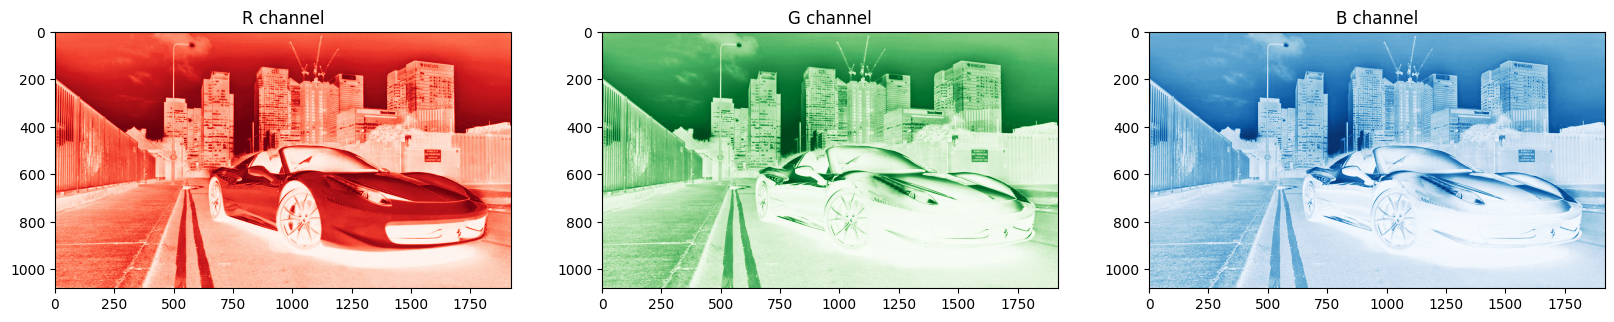

In [19]:
plt.figure(figsize = (20, 10))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds", vmin=0, vmax=255)
plt.title("R channel")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens", vmin=0, vmax=255)
plt.title("G channel")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues", vmin=0, vmax=255)
plt.title("B channel")

plt.show()